In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("train.csv", usecols=["Age", "Fare", "Survived"])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0], test_size=0.2, random_state=0)

In [19]:
X_train.head()

,Age,Fare
387,36.0,13.0000
685,25.0,41.5792
20,35.0,26.0000
331,45.5,28.5000
396,31.0,7.8542


In [12]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

accuracy_score(y_test, y_pred)

0.6223776223776224

In [17]:
np.mean(cross_val_score(DecisionTreeClassifier(), df.iloc[:,1:], df.iloc[:,0], cv = 20, scoring="accuracy"))

0.6356349206349206

# Binning(descretization)

In [55]:
kbins_age = KBinsDiscretizer(n_bins=10, encode = "ordinal", strategy="uniform")
kbins_fare = KBinsDiscretizer(n_bins=10, encode= "ordinal", strategy= "quantile")

In [56]:
trf = ColumnTransformer([
    ("first", kbins_age, [0]),
    ("second", kbins_fare, [1])
])

In [57]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


In [58]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='uniform'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [59]:
trf.named_transformers_["first"].n_bins_

array([10])

In [60]:
trf.named_transformers_["second"].n_bins_

array([10])

In [61]:
trf.named_transformers_["first"].bin_edges_

array([array([ 0.67 ,  8.603, 16.536, 24.469, 32.402, 40.335, 48.268, 56.201,
              64.134, 72.067, 80.   ])                                       ],
      dtype=object)

In [62]:
trf.named_transformers_["second"].bin_edges_

array([array([  0.    ,   7.7417,   7.8958,   8.6625,  12.35  ,  15.5   ,
               25.9292,  27.9   ,  39.6875,  78.2667, 512.3292])         ],
      dtype=object)

In [63]:
output = pd.DataFrame({
    "age":X_train["Age"],
    "age_trf":X_train_trf[:,0],
    "fare":X_train["Fare"],
    "fare_trf":X_train_trf[:,1]
})

In [67]:
output["age_labels"] = pd.cut(x= X_train["Age"], bins =trf.named_transformers_["first"].bin_edges_[0].tolist())
output["fare_labels"] = pd.cut(x= X_train["Fare"], bins =trf.named_transformers_["second"].bin_edges_[0].tolist())

In [68]:
output.head()

,age,age_trf,fare,fare_trf,age_labels,fare_labels
387,36.0,4.0,13.0000,4.0,"(32.402, 40.335]","(12.35, 15.5]"
685,25.0,3.0,41.5792,8.0,"(24.469, 32.402]","(39.688, 78.267]"
20,35.0,4.0,26.0000,6.0,"(32.402, 40.335]","(25.929, 27.9]"
331,45.5,5.0,28.5000,7.0,"(40.335, 48.268]","(27.9, 39.688]"
396,31.0,3.0,7.8542,1.0,"(24.469, 32.402]","(7.742, 7.896]"


In [69]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [70]:
accuracy_score(y_test,y_pred2)

0.6433566433566433

In [76]:
np.mean(cross_val_score(DecisionTreeClassifier(), df.iloc[:,1:], df.iloc[:,0], scoring="accuracy", cv=20))

0.6384920634920634

In [79]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [81]:
def descretizer(bins, strategy):
    kbins_age = KBinsDiscretizer(n_bins=bins, encode = "ordinal", strategy=strategy)
    kbins_fare = KBinsDiscretizer(n_bins=bins, encode= "ordinal", strategy= strategy)

    trf = ColumnTransformer([
    ("first", kbins_age, [0]),
    ("second", kbins_fare, [1])
    ])

    X_train_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y, scoring="accuracy", cv=20)))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X["Age"])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_train_trf[:,0], color = "red")
    plt.title("After")

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X["Fare"])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_train_trf[:,1], color = "red")
    plt.title("After")

    plt.show()


0.6357539682539681


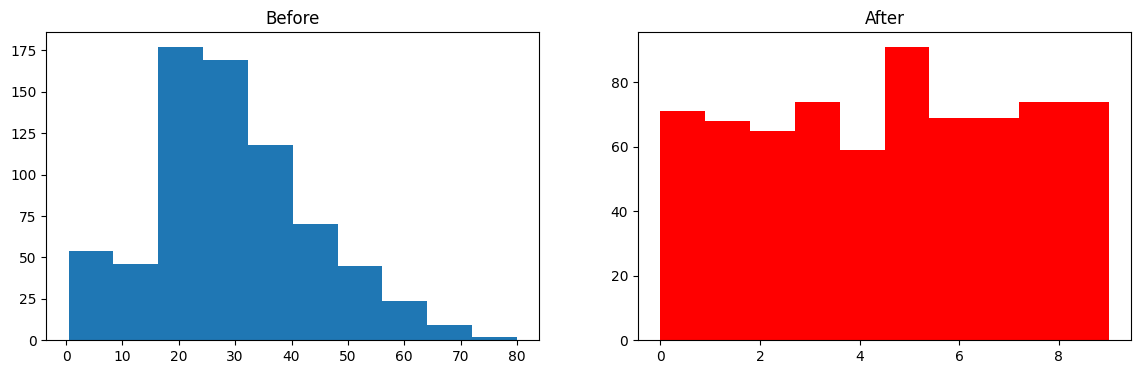

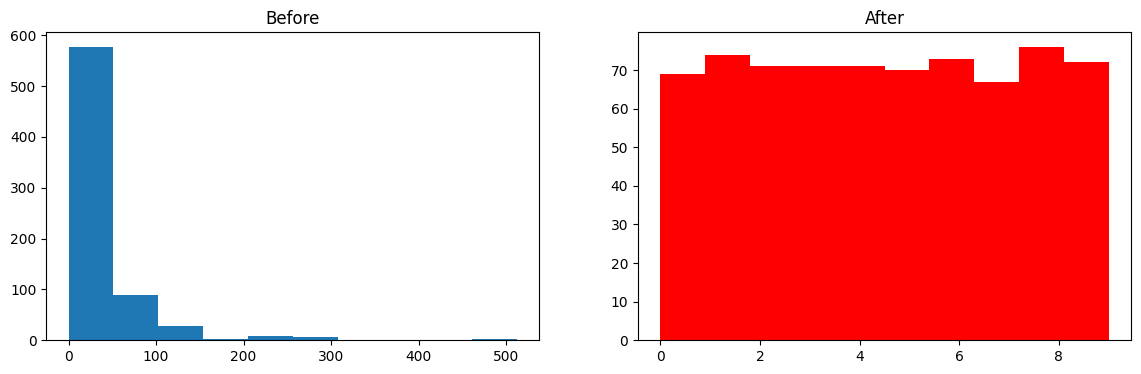

In [84]:
descretizer(10, "quantile")

# binarization

In [85]:
from sklearn.preprocessing import Binarizer

In [86]:
df1 = pd.read_csv("train.csv")

In [87]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
df2 = df1.iloc[:,[1,5,6,7,9]]

In [91]:
df2.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [92]:
df2.dropna(inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_18216\1761232742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.dropna(inplace=True)


In [93]:
df2["Family"] = df2["SibSp"] + df2["Parch"]

C:\Users\kumar\AppData\Local\Temp\ipykernel_18216\976936003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Family"] = df2["SibSp"] + df2["Parch"]


In [94]:
df2.head()

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [102]:
df2.drop(columns=["SibSp", "Parch"], inplace= True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_18216\3221179109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(columns=["SibSp", "Parch"], inplace= True)


In [103]:
X = df2.drop(columns="Survived", axis =1)
y = df2["Survived"]

In [104]:
X.head()

,Age,Fare,Family
0,22.0,7.2500,1
1,38.0,71.2833,1
2,26.0,7.9250,0
3,35.0,53.1000,1
4,35.0,8.0500,0


In [105]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [106]:
X_train.head()

,Age,Fare,Family
387,36.0,13.0000,0
685,25.0,41.5792,3
20,35.0,26.0000,0
331,45.5,28.5000,0
396,31.0,7.8542,0


In [107]:
y_train.tail()

883    0
238    0
789    0
704    0
856    1
Name: Survived, dtype: int64

In [112]:
# without binarization 
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.6013986013986014

In [118]:
np.mean(cross_val_score(DecisionTreeClassifier(), X,y,scoring="accuracy", cv=20))

0.6540873015873014

In [119]:
# applying binarization
from sklearn.preprocessing import Binarizer

In [121]:
trf = ColumnTransformer([
    ("bin", Binarizer(copy=False), ["Family"])
], remainder="passthrough")

In [123]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [124]:
X_train_trf

array([[  0.    ,  36.    ,  13.    ],
       [  1.    ,  25.    ,  41.5792],
       [  0.    ,  35.    ,  26.    ],
       ...,
       [  0.    ,  46.    ,  79.2   ],
       [  1.    ,  26.    ,   7.8542],
       [  1.    ,  45.    , 164.8667]])

In [127]:
pd.DataFrame(X_train_trf, columns=["Family", "Age", "Fare"])

,Family,Age,Fare
0,0.0,36.0,13.0000
1,1.0,25.0,41.5792
2,0.0,35.0,26.0000
3,0.0,45.5,28.5000
4,0.0,31.0,7.8542
...,...,...,...
566,0.0,28.0,10.5000
567,0.0,19.0,10.5000
568,0.0,46.0,79.2000
569,1.0,26.0,7.8542


In [128]:
clf2 = DecisionTreeClassifier()
clf2.fit(X_train_trf, y_train)
y_pred2 = clf2.predict(X_test_trf)

accuracy_score(y_test, y_pred2)

0.6223776223776224

In [132]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X_trf,y,scoring="accuracy", cv=20))

0.6189285714285713